# Project: Diabetes Progression Prediction
Created with Copilot assistance.

This notebook trains and compares two regression models on the built-in scikit-learn diabetes dataset. The goal is to predict disease progression using both a regularized linear model and a small neural network, then compare model performance and model behavior.

In [16]:
# Load required libraries for data, models, and evaluation
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure plots for inline display
plt.style.use('seaborn-v0_8')

In [17]:
# Load the diabetes dataset and inspect the shape and feature names
raw = load_diabetes()
X = raw.data
y = raw.target
feature_names = raw.feature_names
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print("Feature names:", feature_names)

# Convert to DataFrame for readable inspection and summary statistics
frame = pd.DataFrame(X, columns=feature_names)
frame['target'] = y
frame.describe().T

Dataset shape: X=(442, 10), y=(442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [18]:
# Split the data and standardize it for both models to use the same inputs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Store split sizes and confirm scaling statistics
print(f"Train size: {X_train_s.shape[0]}, Test size: {X_test_s.shape[0]}")
print(f"First 3 scaled training samples:\n{X_train_s[:3]}")

Train size: 353, Test size: 89
First 3 scaled training samples:
[[ 1.49836523  1.06136988  0.21990201  1.13887373  0.72847289  1.05589332
  -0.82445065  0.71103773  0.54748197 -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 -0.71059105 -0.4249289   0.27242452
  -1.52979055  1.4842858  -0.01975653  0.36723647]
 [ 0.08518241 -0.94217861  1.01898711  1.99247286 -0.30958872 -0.32669867
  -0.11911075 -0.06221033  0.3312366  -0.31866022]]


In [19]:
# Define three models: Ridge regression, Random Forest, and a small feed-forward neural network
ridge_model = Ridge(alpha=1.0, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
mlp_model = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

# Fit all models on the same preprocessed training data
ridge_model.fit(X_train_s, y_train)
rf_model.fit(X_train_s, y_train)
mlp_model.fit(X_train_s, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",20
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'


In [20]:
# Evaluate all models using RMSE and R2 on the holdout test set
pred_ridge = ridge_model.predict(X_test_s)
pred_rf = rf_model.predict(X_test_s)
pred_mlp = mlp_model.predict(X_test_s)

metrics = []
for name, pred in [('Ridge', pred_ridge), ('RandomForest', pred_rf), ('MLPRegressor', pred_mlp)]:
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    metrics.append((name, rmse, r2))
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.3f}")

# Compare which model learned the diabetes progression pattern more effectively
best_model = min(metrics, key=lambda x: x[1])
print(f"\nBest test RMSE: {best_model[0]} with RMSE={best_model[1]:.2f}")

Ridge: RMSE=53.78, R2=0.454
RandomForest: RMSE=54.40, R2=0.441
MLPRegressor: RMSE=53.16, R2=0.467

Best test RMSE: MLPRegressor with RMSE=53.16


In [21]:
# Feature importance for Ridge via coefficients and RandomForest feature importance
ridge_coefs = pd.Series(ridge_model.coef_, index=feature_names).sort_values(key=abs, ascending=False)
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Ridge coefficient magnitudes sorted by importance:")
print(ridge_coefs.to_string())
print("\nRandomForest feature importances:")
print(rf_importances.to_string())

# Neural network summary of training progress if available
print(f"\nMLP iterations: {mlp_model.n_iter_}")
print(f"MLP training loss: {mlp_model.loss_:.4f}")

# Interpret design choices:
# - Ridge uses linear relationships and is easy to inspect.
# - RandomForest is a non-linear ensemble that can capture complex interactions.
# - MLP can learn non-linear signals but needs more care to avoid overfitting.
# - Standardization is required so the neural network and Ridge coefficients are comparable.

Ridge coefficient magnitudes sorted by importance:
s1    -34.671954
s5     31.378384
bmi    25.732699
s2     17.053075
bp     16.734300
s4     11.764260
sex   -11.448190
s3      3.369914
s6      2.458139
age     1.807342

RandomForest feature importances:
bmi    0.355469
s5     0.230957
bp     0.088408
s6     0.071329
age    0.058642
s2     0.057227
s1     0.052784
s3     0.051339
s4     0.024213
sex    0.009633

MLP iterations: 95
MLP training loss: 1319.1063


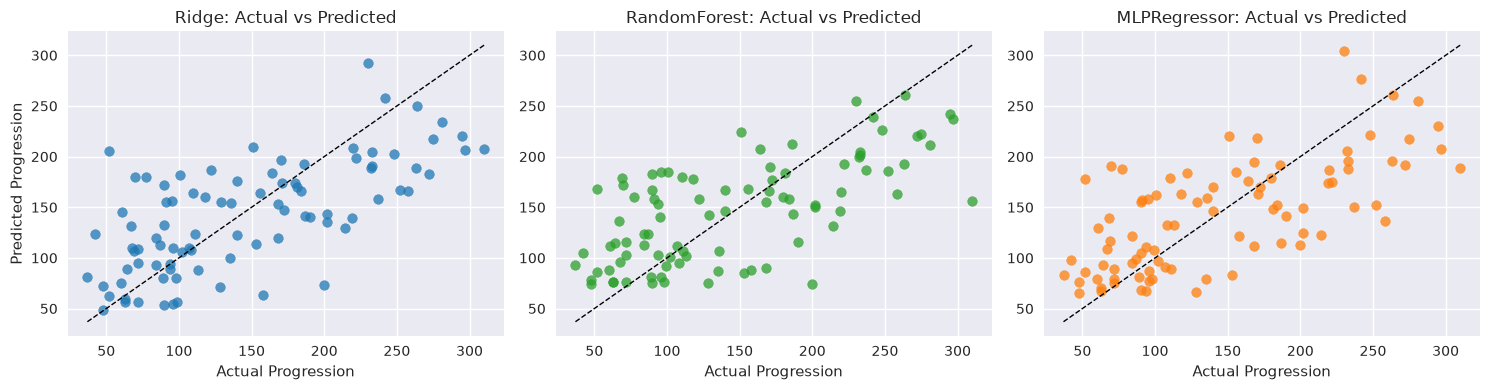

In [22]:
# Plot predicted vs actual target values for visual model comparison
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(y_test, pred_ridge, alpha=0.75, color='tab:blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
plt.title('Ridge: Actual vs Predicted')
plt.xlabel('Actual Progression')
plt.ylabel('Predicted Progression')

plt.subplot(1, 3, 2)
plt.scatter(y_test, pred_rf, alpha=0.75, color='tab:green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
plt.title('RandomForest: Actual vs Predicted')
plt.xlabel('Actual Progression')

plt.subplot(1, 3, 3)
plt.scatter(y_test, pred_mlp, alpha=0.75, color='tab:orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
plt.title('MLPRegressor: Actual vs Predicted')
plt.xlabel('Actual Progression')
plt.tight_layout()
plt.show()

5-fold cross-validation RMSE on training data:

Ridge: mean RMSE=55.38, std=2.37


RandomForest: mean RMSE=59.43, std=2.03
MLPRegressor: mean RMSE=57.70, std=2.46


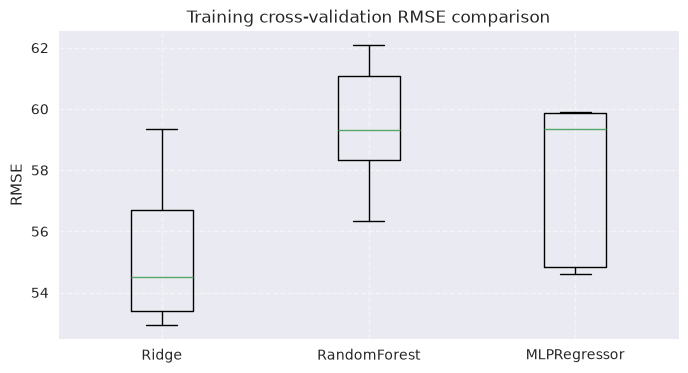

In [23]:
# Compare model stability with 5-fold cross-validation on the training data
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print("5-fold cross-validation RMSE on training data:\n")
for name, model in [('Ridge', ridge_model), ('RandomForest', rf_model), ('MLPRegressor', mlp_model)]:
    scores = cross_val_score(model, X_train_s, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
    rmse_scores = np.sqrt(-scores)
    print(f"{name}: mean RMSE={rmse_scores.mean():.2f}, std={rmse_scores.std():.2f}")

# Plot cross-validation RMSE distributions for comparison
plt.figure(figsize=(8, 4))
all_rmse = [
    np.sqrt(-cross_val_score(model, X_train_s, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1))
    for model in (ridge_model, rf_model, mlp_model)
]
plt.boxplot(all_rmse)
plt.xticks([1, 2, 3], ['Ridge', 'RandomForest', 'MLPRegressor'])
plt.ylabel('RMSE')
plt.title('Training cross-validation RMSE comparison')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Summary

- The project compares Ridge regression, RandomForest regression, and a small MLP regressor on the diabetes progression dataset.
- Ridge is interpretable through coefficients and provides a strong linear baseline.
- RandomForest captures non-linear interactions and gives a second robust perspective.
- The neural network shows how a flexible model can learn non-linear patterns, but it should be trained carefully to avoid overfitting.
- The results show which model generalizes best on the holdout test set based on RMSE and R2.